# Joint clustering of  CD8+ T cells


These notebooks contain the code to annotate the data in our CD8 T cells dataset (the CD8 T cell compartment of the multi-omic scATAC+RNA-seq dataset collected at day 7 post-infection with the Armstrong (acute) or clone 13 (chronic) strains of lymphocytic choriomeningitis virus (LCMV)). 

The RNA matrix for both clones filtered for CD8 T cells (rna_CD8.h5ad), corresponding ATAC matrix (atac_CD8.h5ad)  and peaks-to-genes map (nearest_genes_to_summits.distances.csv) can be downloaded at https://doi.org/10.6084/m9.figshare.31843234

The preprocessed adata_rna and adata_atac_raw anndata objects used for ArchVelo analysis of each clone should be downloaded into the processed_data/arm/ and processed_data/cl13/ folders respectively. 

In [1]:
import numpy as np
import pandas as pd

In [2]:
import os

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import scanpy as sc
import anndata

In [5]:
from scipy.sparse import csr_matrix

In [6]:
data_outdir = 'processed_data/2_clones/'
os.makedirs(data_outdir, exist_ok = True)

In [7]:
num_comps = 9

In [8]:
import os
fig_outdir = 'figures/2_clones/'
os.makedirs(fig_outdir, exist_ok = True)

# Preprocess data

In [9]:
adata_rna = sc.read_h5ad('data/2_clones/rna_CD8.h5ad')

In [10]:
adata_rna_full = adata_rna.copy()

In [15]:
import scvelo as scv
adata_rna.X = adata_rna.layers['raw_counts'].copy()
scv.pp.filter_and_normalize(adata_rna, min_shared_counts = 30)

Filtered out 7696 genes that are detected 30 counts (shared).
Normalized count data: X, spliced, unspliced.


/mnt/home/mavdeeva/Software/VENVs/arch-RR/lib/python3.11/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


Logarithmized X.


In [16]:
adata_rna.layers['log1p'] = adata_rna.X.copy()

In [17]:
# for visualization
adat_copy = adata_rna_full.copy()
adat_copy.X = adat_copy.layers['raw_counts'].copy()
scv.pp.filter_and_normalize(adat_copy, min_shared_counts = 0)#, n_top_genes = 1500)
adat_copy.layers['log1p'] = adat_copy.X.copy()

Normalized count data: X, spliced, unspliced.


/mnt/home/mavdeeva/Software/VENVs/arch-RR/lib/python3.11/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


Logarithmized X.


In [18]:
adata_rna_arm = sc.read_h5ad('processed_data/arm/adata_rna.h5ad')
adata_rna_cl13 = sc.read_h5ad('processed_data/cl13/adata_rna.h5ad')

In [19]:
both_genes = np.unique(list(adata_rna_arm.var_names)+list(adata_rna_cl13.var_names))
len(both_genes)

2058

In [20]:
# load 2 clones and filter only to genes in at least 1 clones
adata_rna = adata_rna[:, both_genes]

In [21]:
adata_rna.X = adata_rna.layers['theta_10'].copy()

In [22]:
n_neigh = 30
n_pcs = 50
met = 'cosine'
res = 1.5
rand_st = 3
np.random.seed(rand_st)

In [23]:
sc.pp.pca(adata_rna, n_pcs, random_state = rand_st)
sc.pp.neighbors(adata_rna, n_neighbors=n_neigh, n_pcs=n_pcs, 
                            metric = met, random_state = rand_st)


In [24]:
sc.tl.umap(adata_rna, random_state = rand_st)


In [25]:
marks_full =  pd.Index(['Pola1','Pcna', 'Top2a', 'Mki67', 'Cdc20',
                  'Klrg1', 'Gzma', 'Gzmk','Gzmb', 
                  'Ccl5','Ccr2',  
                  'Il7r','Sell', 'Ccr7',
                  'Nt5e','Cxcr5','Bcl6', 'Id3','Tcf7', 'Slamf6', 'Ccr6', 'Nfat5', #'Ctla4',
         #'Prf1',  
         'Tox','Pdcd1',  'Lag3', 'Cd160','Prf1','Havcr2','Il2ra','Xcl1','Ccl3','Ccl4','Ifng',])

In [26]:
marks = marks_full.intersection(adata_rna.var_names)

In [27]:
sc.tl.leiden(adata_rna, resolution = 2, random_state = rand_st)

In [28]:
np.random.seed(rand_st)
num_clusts = len(adata_rna.obs['leiden'].cat.categories)
pal = dict(zip(adata_rna.obs['leiden'].cat.categories,
               list(np.array(sns.color_palette('husl', num_clusts))[np.random.choice(num_clusts,num_clusts, replace = False)])))

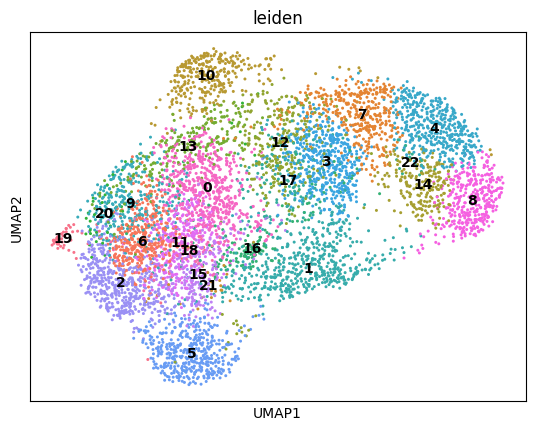

In [30]:
sc.pl.umap(adata_rna, 
           color = ['leiden'],
          palette = pal,
          legend_loc = 'on data')

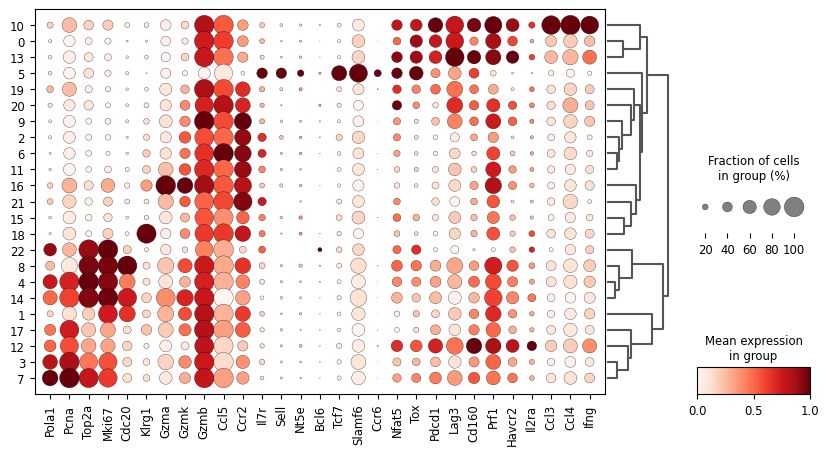

In [31]:
sc.tl.dendrogram(adata_rna,groupby = 'leiden')
sc.pl.dotplot(adata_rna, marks, groupby = 'leiden',layer = 'log1p',
             standard_scale = 'var', figsize = (10,5),
                   dendrogram = True)

In [32]:
def coarse(cl):
    if cl in ['13', '0', ] :
        return 'Inter exh'
    elif cl == '5':
        return 'Prog'
    elif cl in ['21', '6',  '2']:
        return 'Il7r+ eff'
    elif cl in ['11', '15', '20', '19', '9']:
        return 'Inter eff'
    # elif cl == '5':
    #     return 'Il7r+Klrg1+ Eff'
    elif cl in [ '18']:
        return 'Klrg1+ eff'
    elif cl in [ '16']:
        return 'Gzm+ eff'
    elif cl in ['12', '17', '3', '7']:
        return 'S'
    elif cl in ['22', '8', '4', '14']:
        return 'G2M.1'
    elif cl == '1':
        return 'G2M.2'
    elif cl == '10':
        return 'Exh'
    else:
        return 'Other'

In [33]:
adata_rna.obs['coarse'] = adata_rna.obs['leiden'].map(coarse)


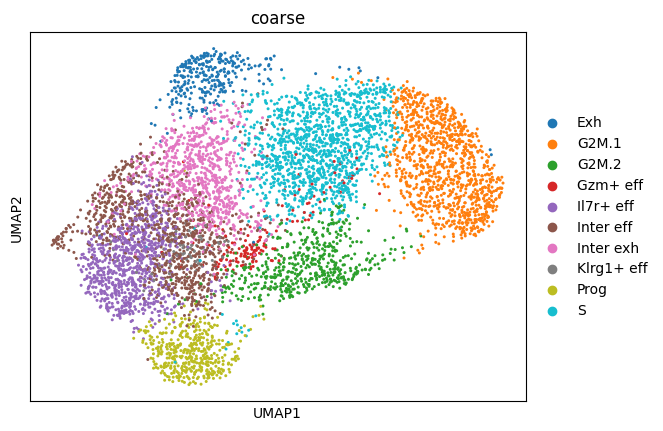

In [34]:
sc.pl.umap(adata_rna, color = ['coarse', ], layer = 'log1p'
                               )

In [35]:
sns.set(style = 'ticks', font_scale = 1.)

In [36]:
ct_order = [ 'S', 'G2M.1', 'G2M.2', 'Inter eff', 'Klrg1+ eff', 'Gzm+ eff',  'Il7r+ eff', 'Inter exh', 'Exh','Prog']


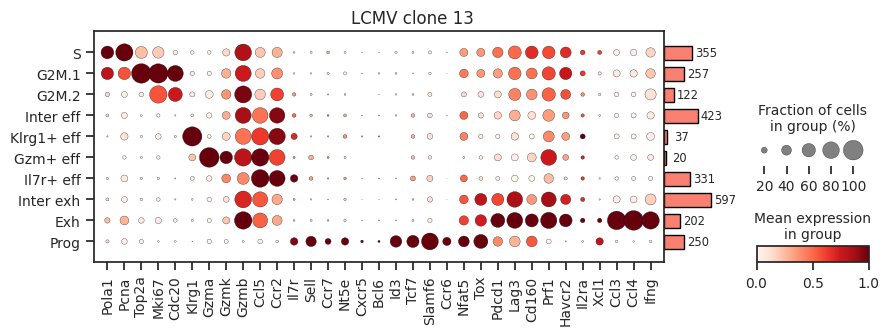

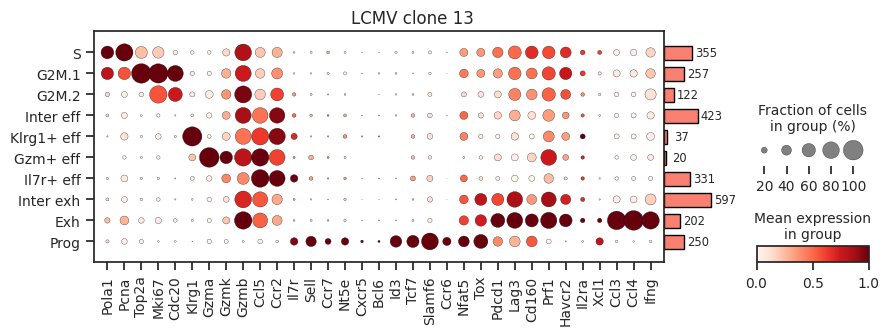

In [37]:
cur_dat = adat_copy[adata_rna.obs.index,:][adata_rna.obs['type'] == 'cl13',:].copy()
cur_dat.X = cur_dat.layers['theta_10']
cur_dat.obs['coarse'] = adata_rna[cur_dat.obs.index,:].obs['coarse']
adata_rna_cl13_full = cur_dat.copy()
sc.tl.dendrogram(cur_dat,groupby = 'coarse')
dp = sc.pl.dotplot(cur_dat, marks_full, groupby = 'coarse',#layer = 'log1p',
             standard_scale = 'var', figsize = (10,3),
              title = 'LCMV clone 13', return_fig=True, show = False,
                   #title_fontsize = 25,
                   categories_order = ct_order,
                   dendrogram = False)
dp.add_totals()#.style(dot_edge_color='black', dot_edge_lw=0.5, cmap = 'Reds')#.show()
#plt.tight_layout()
dp.savefig(fig_outdir+'clone_13_coarse.png', dpi = 500)
dp.savefig(fig_outdir+'clone_13_coarse.svg', dpi = 500)

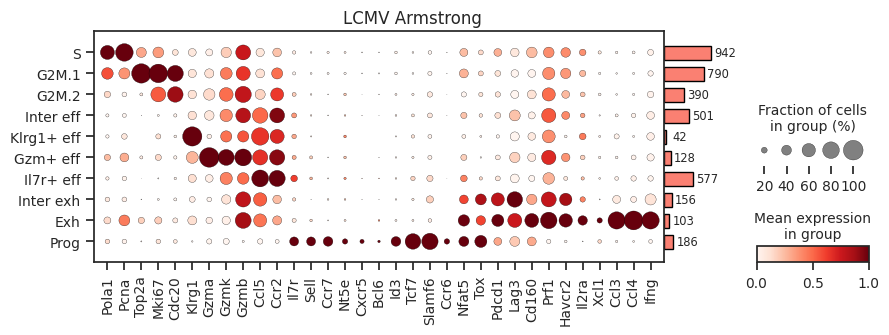

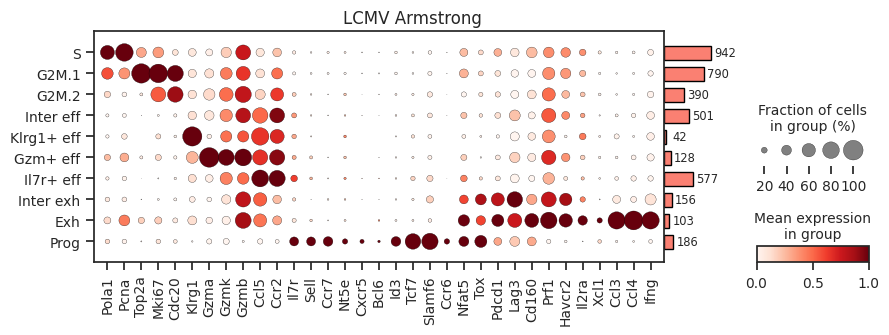

In [38]:
cur_dat = adat_copy[adata_rna.obs.index,:][adata_rna.obs['type'] == 'arm',:].copy()
cur_dat.X = cur_dat.layers['theta_10']
cur_dat.obs['coarse'] = adata_rna[cur_dat.obs.index,:].obs['coarse']
adata_rna_arm_full = cur_dat.copy()
sc.tl.dendrogram(cur_dat,groupby = 'coarse')
dp = sc.pl.dotplot(cur_dat, marks_full, groupby = 'coarse',#layer = 'log1p',
             standard_scale = 'var', figsize = (10,3),
              title = 'LCMV Armstrong', return_fig=True, show = False,
                   categories_order = ct_order,
                   dendrogram = False)
dp.add_totals()#.style(dot_edge_color='black', dot_edge_lw=0.5).show()
#plt.tight_layout()
dp.savefig(fig_outdir+'arm_coarse.png', dpi = 500)
dp.savefig(fig_outdir+'arm_coarse.svg', dpi = 500)

In [39]:
cop = adata_rna[adata_rna.obs['coarse'] == 'Prog',:].copy()
sc.tl.leiden(cop, resolution = 0.4, random_state = rand_st)

In [40]:
leidens = np.array(adata_rna.obs['coarse'])
leidens[leidens == 'Prog'] = ['Ccr6+ prog' if x == '0' else 'Ccr6- prog' for x in cop.obs['leiden'].values]
adata_rna.obs['small_coarse'] = pd.Series(leidens, index = adata_rna.obs_names).astype('category')

In [41]:
sns.set(style = 'ticks', font_scale = 1.3)

In [42]:
adata_rna_no_cycle = adata_rna[~adata_rna.obs['coarse'].isin(['S', 'G2M.1', 'G2M.2']),:].copy()
total_cells = {}
for cl in ['arm', 'cl13']:
    total_cells[cl] = adata_rna_no_cycle[adata_rna_no_cycle.obs['type'] ==cl,:].shape[0]
total_cells_prop = total_cells['arm']/(total_cells['arm']+total_cells['cl13'])
num_cells_no_cycle = {}
for cl in ['arm', 'cl13']:
    num_cells_no_cycle[cl] = adata_rna_no_cycle[adata_rna_no_cycle.obs['type'] ==cl,:].obs['coarse'].value_counts()
num_cells_no_cycle = pd.DataFrame(num_cells_no_cycle)
norm_to_plot = num_cells_no_cycle.div(num_cells_no_cycle.sum(1),0)

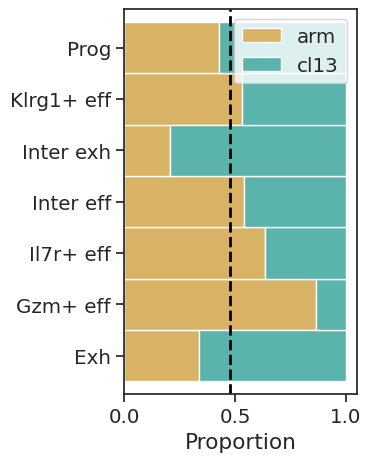

In [43]:
norm_to_plot.plot.barh(stacked = True, figsize = (3,5), width = 1, color = ['#d8b365', '#5ab4ac'])
plt.axvline(total_cells_prop, linestyle = 'dashed', lw = 2, color = 'black')
plt.ylabel('')
plt.xlabel('Proportion')
plt.savefig(fig_outdir+'props_no_cycle.png', dpi = 500)
plt.savefig(fig_outdir+'props_no_cycle.svg', dpi = 500)

## Progenitor subtypes

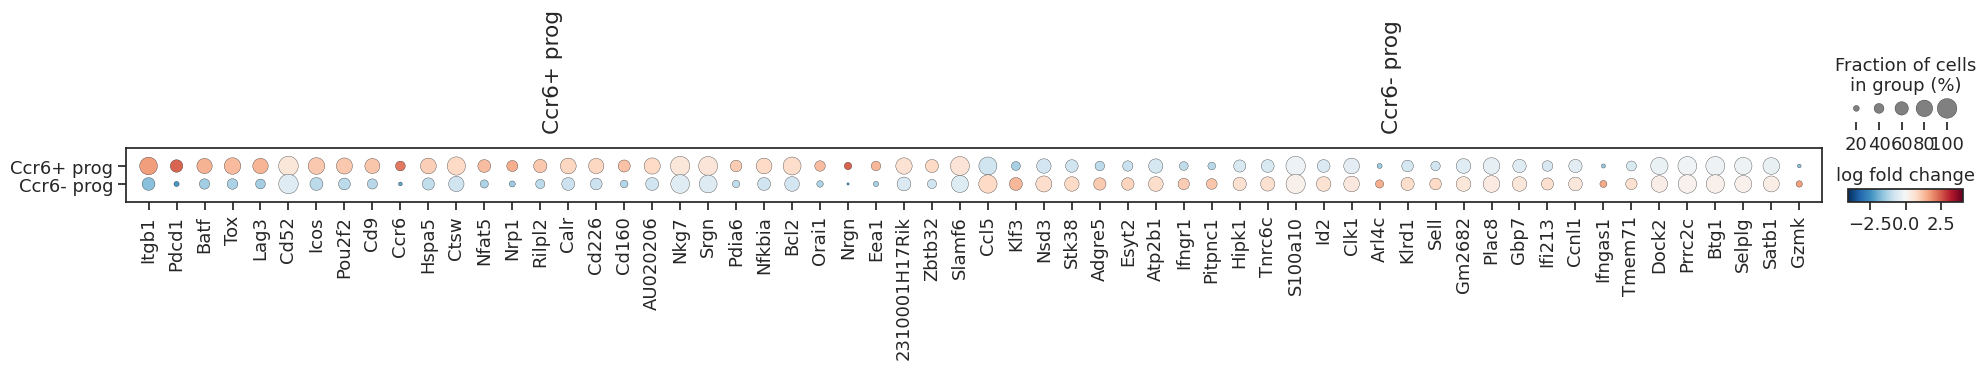

In [44]:
only_prog = adata_rna[adata_rna.obs['coarse'] == 'Prog',:].copy()
sc.tl.rank_genes_groups(only_prog, 
                        groupby = 'small_coarse',
                        use_raw = False,
                        layer = 'log1p',
                        method = 'wilcoxon')
sc.tl.dendrogram(only_prog, 
                        groupby = 'small_coarse')
sc.pl.rank_genes_groups_dotplot(only_prog, 
                                layer = 'log1p',
                        groupby = 'small_coarse',
                        n_genes = 30,
                        values_to_plot = 'logfoldchanges',
                        vmin = -4, vmax = 4,
                        cmap = 'RdBu_r')
                        

In [45]:
ct_order = [ 'Ccr6- prog', 'Ccr6+ prog']

In [46]:
def map_to_other(x):
    if x in ct_order:
        return x
    else:
        return 'Other'
adata_rna.obs['prog_other'] = adata_rna.obs['small_coarse'].map(map_to_other).astype('category')

In [47]:
adat_copy.obs['prog_other'] = adata_rna.obs['prog_other']

In [48]:
prog_marks = pd.Index(['Tcf7', 'Slamf6', 'Id3','Nt5e', 'Cxcr5',  'Sell', 'Il7r'])

In [49]:
prog_de_marks = pd.Index(['Bach2','Myb','Dapl1', 'Ccr7','Sell', 'Lef1', 'Satb1']+
                  ['Klf3',  'Arl4c','Klrd1', 'Ifngr1' ,'Ccl5',  'Id3','Tox', 'Itgb1', 'Nfat5','Cd160','Batf', 'Pdcd1', 'Lag3',
                    'Xcl1',  'Ccr6' ])#'Ccr7','Xcl1',
    #'Klrd1', 'Ifngr1', 'Satb1','Il7r','Id2','Prf1',  'Nfat5', 'Nkg7',


In [50]:
prog_marks_all = pd.Index(list(prog_marks)+list(prog_de_marks)).unique()

In [51]:
cur_dat = adat_copy[adat_copy.obs['type'] == 'arm',:].copy()
cur_dat.X = cur_dat.layers['theta_10']
cur_dat.obs['small_coarse'] = adata_rna[cur_dat.obs.index,:].obs['small_coarse']
cur_dat.obs['prog_other'] = adata_rna[cur_dat.obs.index,:].obs['prog_other']


In [52]:
sns.set(style = 'ticks', font_scale = 1.3)

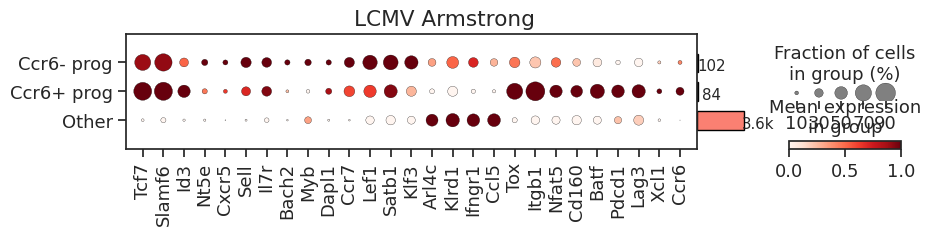

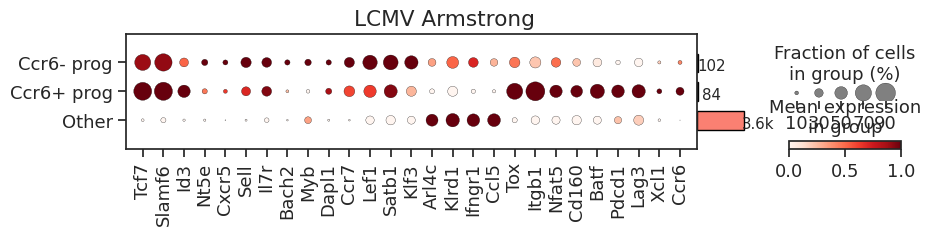

In [53]:
sc.tl.dendrogram(cur_dat,groupby = 'prog_other')
dp = sc.pl.dotplot(cur_dat, prog_marks_all, 
                   groupby = 'prog_other',#layer = 'log1p',
                   standard_scale = 'var', 
                   figsize = (10,1.5),
                   title = 'LCMV Armstrong', 
                   return_fig=True, 
                   show = False,
                   categories_order = ct_order+['Other'],
                   dendrogram = False,
                  ).add_totals()
dp.savefig(fig_outdir+'prog_marks_all_arm_new.png', dpi = 500)
dp.savefig(fig_outdir+'prog_marks_all_arm_new.svg', dpi = 500)

In [54]:
cur_dat = adat_copy[adat_copy.obs['type'] == 'cl13',:].copy()
cur_dat.X = cur_dat.layers['theta_10']
cur_dat.obs['small_coarse'] = adata_rna[cur_dat.obs.index,:].obs['small_coarse']
cur_dat.obs['prog_other'] = adata_rna[cur_dat.obs.index,:].obs['prog_other']


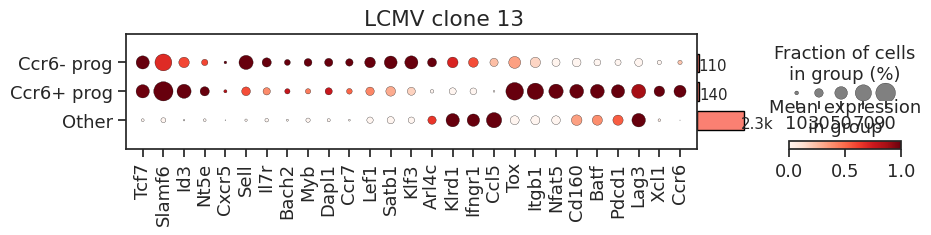

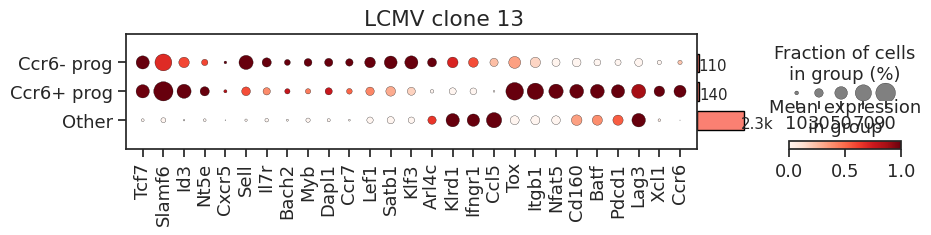

In [55]:
sc.tl.dendrogram(cur_dat,groupby = 'prog_other')
dp = sc.pl.dotplot(cur_dat, prog_marks_all, 
                   groupby = 'prog_other',#layer = 'log1p',
                   standard_scale = 'var', 
                   figsize = (10,1.5),
                   title = 'LCMV clone 13', 
                   return_fig=True, 
                   show = False,
                   categories_order = ct_order+['Other'],
                   dendrogram = False,
                  ).add_totals()#.style(dot_edge_color='black', dot_edge_lw=0.5).show()
dp.savefig(fig_outdir+'prog_marks_all_cl13_new.png', dpi = 500)
dp.savefig(fig_outdir+'prog_marks_all_cl13_new.svg', dpi = 500)

In [56]:
adata_rna.write('processed_data/2_clones/adata_rna.h5ad')